In [1]:
# ==========================================
# EXPERIMENT 4
# EXPLAINABILITY + LLM + RAG
# ==========================================

import os
import joblib
import numpy as np
import pandas as pd

print("=" * 60)
print("EXPERIMENT 4 STARTED")
print("=" * 60)

EXPERIMENT 4 STARTED


In [2]:
# ==========================================
# LOAD RANDOM FOREST MODEL OF EXPERIMENT 2
# ==========================================
Exp2_path="exp_2_result"

rf_model=joblib.load(os.path.join(
    Exp2_path,
    "experiment2_random_forest.pkl"))

hybrid_config=joblib.load(os.path.join(
    Exp2_path,
    "experiment2_hybrid_config.pkl"
))

FEATURE_COLUMNS=hybrid_config["feature_columns"]

print("Random Forest loaded successfully.")
print("Number of features:", len(FEATURE_COLUMNS))
print("\nFeatures:")
print(FEATURE_COLUMNS)

Random Forest loaded successfully.
Number of features: 67

Features:
Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count

In [3]:
# ==========================================
# LOAD 2018 DATA FOR EXPLANATION
# ==========================================

EXP3_DATA_PATH="data_2018"
print("Looking for 2018 parquet files...")

files_2018=[]

for root,dir,files in os.walk(EXP3_DATA_PATH):
    for file in files:
        if file.lower().endswith(".parquet"):
            files_2018.append(
                os.path.join(root,file)
            )

print("2018 parquet files found:", len(files_2018))

for file in files_2018[:10]:
    print(os.path.basename(file))


Looking for 2018 parquet files...
2018 parquet files found: 10
Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet
Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet
DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet
DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet
DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet
DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet
Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet
Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet
Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet
Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet


In [4]:
# ==========================================
# LOAD A SMALL 2018 SAMPLE
# ==========================================

sample_parts=[]

for file in files_2018:
    df_temp=pd.read_parquet(file)

    #maximum 1000 rows per file

    sample_parts.append(
        df_temp.sample(
            n=min(1000,len(df_temp)),
            random_state=42
        )
    )

    explain_df=pd.concat(
        sample_parts,
        ignore_index=True
    )
print("Explanation dataset shape:")
print(explain_df.shape)

Explanation dataset shape:
(10000, 78)


In [5]:
# ==========================================
# PREPARE FEATURES FOR SHAP
# ==========================================

missing_features=[
    col 
    for col in FEATURE_COLUMNS
    if col not in explain_df.columns
]
print("Missing features:")
print(missing_features)

assert len(missing_features)==0,(
    "Required Feature are Missing"
)
X_explain=explain_df[
    FEATURE_COLUMNS
].copy()

#Replace infinity

X_explain=X_explain.replace(
    [np.inf,-np.inf],
    np.nan
)
#Fill Missing Value Using Train Median

train_median=joblib.load(
    os.path.join(
        Exp2_path,
        "experiment2_train_medians.pkl"
    )
)

for col in FEATURE_COLUMNS:
    if col in train_median.index:
        X_explain[col]=X_explain[col].fillna(
            train_median[col]
        )
print("X_explain shape:", X_explain.shape)

print(
    "Remaining NaN:",
    X_explain.isna().sum().sum()
)       


Missing features:
[]
X_explain shape: (10000, 67)
Remaining NaN: 0


In [6]:
# ==========================================
# GENERATE MODEL PREDICTIONS
# ==========================================

explain_prob=rf_model.predict_proba(
    X_explain
)[:,1]

explain_pred=(
    explain_prob>=0.5
).astype(int)

explain_df["RF_Probability"]=explain_prob
explain_df["RF_Prediction"]=explain_pred

print("Predictions generated.")

print("\nPrediction distribution:")
print(
    pd.Series(
        explain_pred
    ).value_counts()
)




Predictions generated.

Prediction distribution:
0    10000
Name: count, dtype: int64


In [7]:
# ==========================================
# SHAP
# ==========================================

try:
    import shap
    print("SHAP version:" ,shap.__version__)

except ImportError:

    print("SHAP is not installed.")
    print("Run this command in a new cell:")
    print("pip install shap")

SHAP version: 0.51.0


In [8]:
# ==========================================
# CREATE SHAP EXPLAINER
# ==========================================

explainer=shap.TreeExplainer(
    rf_model
)
print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


In [9]:
# ==========================================
# CALCULATE SHAP VALUES
# ==========================================

SHAP_SAMPLE_SIZE = min(
    500,
    len(X_explain)
)

X_shap = X_explain.iloc[
    :SHAP_SAMPLE_SIZE
].copy()

print("SHAP sample shape:")
print(X_shap.shape)

shap_values = explainer.shap_values(
    X_shap
)

print("SHAP values calculated.")

SHAP sample shape:
(500, 67)
SHAP values calculated.


In [10]:
# ==========================================
# INSPECT SHAP OUTPUT
# ==========================================

print("SHAP object type:")
print(type(shap_values))

print("\nSHAP shape:")
print(
    np.array(shap_values).shape
)

SHAP object type:
<class 'numpy.ndarray'>

SHAP shape:
(500, 67, 2)


In [11]:
# ==========================================
# PREPARE SHAP VALUES
# ==========================================

shap_array = np.array(shap_values)

print("Original SHAP shape:", shap_array.shape)

# Different SHAP versions handle
if shap_array.ndim == 3:
    # Usually: samples × features × classes
    shap_attack = shap_array[:, :, 1]

elif shap_array.ndim == 2:
    # Already: samples × features
    shap_attack = shap_array

else:
    raise ValueError(
        f"Unexpected SHAP shape: {shap_array.shape}"
    )

print("Attack SHAP shape:", shap_attack.shape)

print(
    "Expected shape:",
    X_shap.shape
)

Original SHAP shape: (500, 67, 2)
Attack SHAP shape: (500, 67)
Expected shape: (500, 67)


In [12]:
# ==========================================
# GLOBAL SHAP FEATURE IMPORTANCE
# ==========================================

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": np.abs(
        shap_attack
    ).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("Top 20 Important Features:")
display(
    shap_importance.head(20)
)

Top 20 Important Features:


,Feature,Mean_Absolute_SHAP
0,Init Bwd Win Bytes,0.049805
1,Fwd IAT Min,0.036334
2,Init Fwd Win Bytes,0.025478
3,Packet Length Max,0.025341
4,Fwd IAT Std,0.022046
5,Flow Bytes/s,0.021344
6,Fwd Header Length,0.018221
7,Bwd Header Length,0.017604
8,Flow IAT Std,0.016184
9,Subflow Fwd Bytes,0.013816


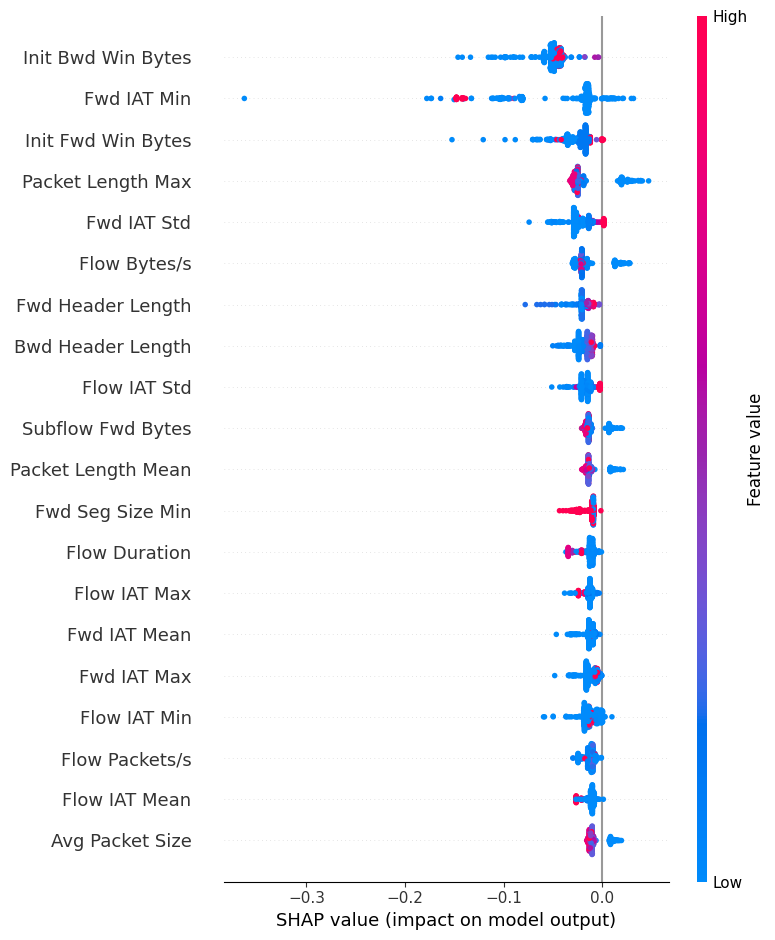

In [13]:
# ==========================================
# SHAP SUMMARY PLOT
# ==========================================

shap.summary_plot(
    shap_attack,
    X_shap,
    max_display=20
)

In [14]:
# ==========================================
# SAVE SHAP FEATURE IMPORTANCE
# ==========================================

EXP4_PATH = "exp_4_result"

os.makedirs(
    EXP4_PATH,
    exist_ok=True
)

shap_importance.to_csv(
    os.path.join(
        EXP4_PATH,
        "shap_feature_importance.csv"
    ),
    index=False
)

print(
    "SHAP feature importance saved."
)

SHAP feature importance saved.


In [16]:
# ==========================================
# SELECT MOST SUSPICIOUS SAMPLE
# ==========================================

attack_idx = int(
    np.argmax(explain_prob)
)

selected_probability = float(
    explain_prob[attack_idx]
)

selected_prediction = int(
    explain_pred[attack_idx]
)

print("=" * 70)
print("MOST SUSPICIOUS SAMPLE")
print("=" * 70)

print("Selected index:", attack_idx)

print(
    "RF attack probability:",
    round(selected_probability, 6)
)

print(
    "RF prediction:",
    "Attack" if selected_prediction == 1 else "Benign"
)

MOST SUSPICIOUS SAMPLE
Selected index: 28
RF attack probability: 0.455
RF prediction: Benign


In [17]:
# ==========================================
# INDIVIDUAL SHAP EXPLANATION
# ==========================================

individual_explanation = pd.DataFrame({

    "Feature": X_shap.columns,

    "SHAP_Value": np.asarray(
        shap_attack[attack_idx]
    ).flatten(),

    "Feature_Value": X_shap.iloc[
        attack_idx
    ].values

})

individual_explanation["Absolute_SHAP"] = (
    individual_explanation["SHAP_Value"].abs()
)

individual_explanation = (
    individual_explanation
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

top_features = individual_explanation.head(10).copy()

print("=" * 70)
print("TOP 10 CONTRIBUTING FEATURES")
print("=" * 70)

display(top_features)

TOP 10 CONTRIBUTING FEATURES


,Feature,SHAP_Value,Feature_Value,Absolute_SHAP
0,Fwd Header Length,-0.077971,72.000000,0.077971
1,Bwd Header Length,-0.050017,32.000000,0.050017
2,Packet Length Max,0.047240,0.000000,0.047240
3,Init Bwd Win Bytes,-0.045383,8192.000000,0.045383
4,Fwd IAT Std,-0.033701,160586.078125,0.033701
5,Flow Bytes/s,0.027417,0.000000,0.027417
6,Flow IAT Std,-0.022757,131450.859375,0.022757
7,Fwd Seg Size Min,-0.021872,20.000000,0.021872
8,Packet Length Mean,0.021584,0.000000,0.021584
9,Fwd IAT Min,0.020659,1474.000000,0.020659


In [19]:
# ==========================================
# STRUCTURED SECURITY EXPLANATION
# ==========================================

prediction_label = (
    "Attack"
    if selected_prediction == 1
    else "Benign / No Attack Detected"
)

attack_explanation = {
    "prediction": prediction_label,
    "rf_probability": selected_probability,
    "top_features": top_features[
        [
            "Feature",
            "Feature_Value",
            "SHAP_Value"
        ]
    ].to_dict("records")
}

print("=" * 70)
print("STRUCTURED SECURITY EXPLANATION")
print("=" * 70)

print("Prediction:", prediction_label)

print(
    "Attack Probability:",
    round(selected_probability, 6)
)

print("\nTop contributing features:")

for item in attack_explanation["top_features"]:

    print(
        f"{item['Feature']} | "
        f"Value={item['Feature_Value']} | "
        f"SHAP={item['SHAP_Value']:.6f}"
    )

STRUCTURED SECURITY EXPLANATION
Prediction: Benign / No Attack Detected
Attack Probability: 0.455

Top contributing features:
Fwd Header Length | Value=72.0 | SHAP=-0.077971
Bwd Header Length | Value=32.0 | SHAP=-0.050017
Packet Length Max | Value=0.0 | SHAP=0.047240
Init Bwd Win Bytes | Value=8192.0 | SHAP=-0.045383
Fwd IAT Std | Value=160586.078125 | SHAP=-0.033701
Flow Bytes/s | Value=0.0 | SHAP=0.027417
Flow IAT Std | Value=131450.859375 | SHAP=-0.022757
Fwd Seg Size Min | Value=20.0 | SHAP=-0.021872
Packet Length Mean | Value=0.0 | SHAP=0.021584
Fwd IAT Min | Value=1474.0 | SHAP=0.020659


In [21]:
# ==========================================
# CREATE FINAL INDIVIDUAL ATTACK EXPLANATION
# ==========================================

# Find predicted attacks
attack_indices = np.where(
    explain_pred == 1
)[0]

print("Detected attack samples:", len(attack_indices))

if len(attack_indices) == 0:

    print("No attack prediction found.")
    print("Cannot create individual explanation.")

else:

    # Select first detected attack
    attack_idx = int(attack_indices[0])

    print("Selected attack index:", attack_idx)

    print(
        "RF probability:",
        round(float(explain_prob[attack_idx]), 6)
    )

    # Directly create SHAP explanation table
    explanation_table = pd.DataFrame({
        "Feature": list(X_shap.columns),
        "SHAP_Value": np.asarray(
            shap_attack[attack_idx]
        ).flatten(),
        "Feature_Value": X_shap.iloc[
            attack_idx
        ].values
    })

    # Absolute SHAP contribution
    explanation_table["Absolute_SHAP"] = (
        explanation_table["SHAP_Value"].abs()
    )

    # Sort by contribution
    explanation_table = explanation_table.sort_values(
        "Absolute_SHAP",
        ascending=False
    ).reset_index(drop=True)

    # Top 10 features
    top_features = explanation_table.head(10).copy()

    print("\n" + "=" * 70)
    print("TOP 10 FEATURES RESPONSIBLE FOR ATTACK PREDICTION")
    print("=" * 70)

    display(top_features)

Detected attack samples: 0
No attack prediction found.
Cannot create individual explanation.


In [22]:
# ==========================================
# CREATE STRUCTURED ATTACK EXPLANATION
# ==========================================

attack_explanation = {
    "prediction": "Attack",
    "rf_probability": float(
        explain_prob[attack_idx]
    ),
    "top_features": top_features[
        [
            "Feature",
            "Feature_Value",
            "SHAP_Value"
        ]
    ].to_dict("records")
}

print("Structured attack explanation created.")

print("\nPrediction:")
print(attack_explanation["prediction"])

print(
    "\nRF Probability:",
    attack_explanation["rf_probability"]
)

print("\nTop contributing features:")

for item in attack_explanation["top_features"]:
    print(
        f"{item['Feature']} | "
        f"Value={item['Feature_Value']} | "
        f"SHAP={item['SHAP_Value']}"
    )

Structured attack explanation created.

Prediction:
Attack

RF Probability: 0.455

Top contributing features:
Fwd Header Length | Value=72.0 | SHAP=-0.07797107030523388
Bwd Header Length | Value=32.0 | SHAP=-0.05001706365692025
Packet Length Max | Value=0.0 | SHAP=0.04723992524762915
Init Bwd Win Bytes | Value=8192.0 | SHAP=-0.04538257012386409
Fwd IAT Std | Value=160586.078125 | SHAP=-0.03370132881575588
Flow Bytes/s | Value=0.0 | SHAP=0.027416552052887073
Flow IAT Std | Value=131450.859375 | SHAP=-0.022756537388113385
Fwd Seg Size Min | Value=20.0 | SHAP=-0.0218724686567072
Packet Length Mean | Value=0.0 | SHAP=0.021584334894803443
Fwd IAT Min | Value=1474.0 | SHAP=0.02065886748374772


## RAG Knowledge Base

In [23]:
# ==========================================
# RAG - SECURITY KNOWLEDGE BASE
# ==========================================

security_documents = [

    {
        "title": "SYN Flood",
        "text": """
        SYN flood attacks generate a large number of TCP SYN requests
        without completing the normal TCP connection process.
        High SYN flag activity, unusual packet rates, and abnormal
        flow behavior can indicate SYN flood or denial-of-service activity.
        """
    },

    {
        "title": "Port Scanning",
        "text": """
        Port scanning attempts to discover open ports and services
        on a target system. Unusual connection patterns, repeated
        short flows, packet-rate anomalies, and abnormal destination
        behavior may indicate scanning activity.
        """
    },

    {
        "title": "Denial of Service",
        "text": """
        Denial-of-Service attacks attempt to make a network service
        unavailable by generating excessive or abnormal traffic.
        High packet rates, high byte rates, unusual flow duration,
        and abnormal packet sizes can be indicators.
        """
    },

    {
        "title": "Web Attack",
        "text": """
        Web attacks target web applications and may include SQL
        injection, cross-site scripting, and brute-force activity.
        Abnormal flow patterns and unusual request behavior can
        indicate malicious web traffic.
        """
    },

    {
        "title": "Botnet Traffic",
        "text": """
        Botnet traffic is generated by compromised systems controlled
        by an attacker. Repeated communication patterns, unusual
        packet behavior, abnormal flow characteristics, and persistent
        network activity can be indicators of botnet communication.
        """
    },

    {
        "title": "Network Anomaly",
        "text": """
        Network anomalies are deviations from normal traffic behavior.
        Abnormal flow duration, packet counts, packet lengths, byte
        rates, inter-arrival times, or TCP flag patterns may indicate
        suspicious activity.
        """
    }
]

print(
    "Security documents:",
    len(security_documents)
)

for doc in security_documents:
    print("-", doc["title"])

Security documents: 6
- SYN Flood
- Port Scanning
- Denial of Service
- Web Attack
- Botnet Traffic
- Network Anomaly


In [24]:
# ==========================================
# RAG KNOWLEDGE BASE DATAFRAME
# ==========================================

knowledge_df = pd.DataFrame(
    security_documents
)

display(knowledge_df)

,title,text
0,SYN Flood,\n SYN flood attacks generate a large n...
1,Port Scanning,\n Port scanning attempts to discover o...
2,Denial of Service,\n Denial-of-Service attacks attempt to...
3,Web Attack,\n Web attacks target web applications ...
4,Botnet Traffic,\n Botnet traffic is generated by compr...
5,Network Anomaly,\n Network anomalies are deviations fro...


In [25]:
# ==========================================
# RAG RETRIEVER
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(
    stop_words="english"
)

knowledge_vectors = vectorizer.fit_transform(
    knowledge_df["text"]
)

print(
    "Knowledge base vectorized successfully."
)

print(
    "Vector shape:",
    knowledge_vectors.shape
)

Knowledge base vectorized successfully.
Vector shape: (6, 78)


In [26]:
# ==========================================
# CREATE RAG QUERY FROM SHAP
# ==========================================

top_feature_names = top_features[
    "Feature"
].tolist()

rag_query = " ".join(
    top_feature_names
)

print("=" * 70)
print("RAG QUERY")
print("=" * 70)

print(rag_query)

RAG QUERY
Fwd Header Length Bwd Header Length Packet Length Max Init Bwd Win Bytes Fwd IAT Std Flow Bytes/s Flow IAT Std Fwd Seg Size Min Packet Length Mean Fwd IAT Min


In [27]:
# ==========================================
# RETRIEVE RELEVANT SECURITY KNOWLEDGE
# ==========================================

query_vector = vectorizer.transform(
    [rag_query]
)

similarities = cosine_similarity(
    query_vector,
    knowledge_vectors
)[0]

knowledge_df["Similarity"] = similarities

retrieved_knowledge = (
    knowledge_df
    .sort_values(
        "Similarity",
        ascending=False
    )
    .head(3)
    .reset_index(drop=True)
)

print("=" * 70)
print("RETRIEVED SECURITY KNOWLEDGE")
print("=" * 70)

display(
    retrieved_knowledge[
        [
            "title",
            "Similarity",
            "text"
        ]
    ]
)

RETRIEVED SECURITY KNOWLEDGE


,title,Similarity,text
0,Network Anomaly,0.279836,\n Network anomalies are deviations fro...
1,Denial of Service,0.245111,\n Denial-of-Service attacks attempt to...
2,Botnet Traffic,0.166057,\n Botnet traffic is generated by compr...


In [28]:
# ==========================================
# PREPARE RAG CONTEXT
# ==========================================

rag_context = "\n\n".join(
    [
        f"Topic: {row['title']}\n"
        f"Knowledge: {row['text'].strip()}"
        for _, row in retrieved_knowledge.iterrows()
    ]
)

print("=" * 70)
print("RAG CONTEXT")
print("=" * 70)

print(rag_context)

RAG CONTEXT
Topic: Network Anomaly
Knowledge: Network anomalies are deviations from normal traffic behavior.
        Abnormal flow duration, packet counts, packet lengths, byte
        rates, inter-arrival times, or TCP flag patterns may indicate
        suspicious activity.

Topic: Denial of Service
Knowledge: Denial-of-Service attacks attempt to make a network service
        unavailable by generating excessive or abnormal traffic.
        High packet rates, high byte rates, unusual flow duration,
        and abnormal packet sizes can be indicators.

Topic: Botnet Traffic
Knowledge: Botnet traffic is generated by compromised systems controlled
        by an attacker. Repeated communication patterns, unusual
        packet behavior, abnormal flow characteristics, and persistent
        network activity can be indicators of botnet communication.


## LLM Prompt Prepare

In [29]:
# ==========================================
# LLM SECURITY EXPLANATION PROMPT
# ==========================================

top_feature_text = "\n".join(
    [
        f"- {row['Feature']}: "
        f"value={row['Feature_Value']}, "
        f"SHAP={row['SHAP_Value']:.6f}"
        for _, row in top_features.iterrows()
    ]
)

llm_prompt = f"""
You are a cybersecurity analyst.

Analyze the following network intrusion detection result.

MODEL PREDICTION:
{prediction_label}

RANDOM FOREST ATTACK PROBABILITY:
{selected_probability:.6f}

TOP SHAP FEATURES:
{top_feature_text}

RETRIEVED CYBERSECURITY KNOWLEDGE:
{rag_context}

TASK:
1. Explain why the model produced this prediction.
2. Identify the most important network features.
3. Explain what the SHAP values indicate.
4. Relate the observed behavior to the retrieved cybersecurity knowledge.
5. Give a concise security interpretation.
6. Do not invent information that is not supported by the provided data.

Return the explanation in clear professional language.
"""

print("=" * 70)
print("LLM PROMPT CREATED")
print("=" * 70)

print(llm_prompt)

LLM PROMPT CREATED

You are a cybersecurity analyst.

Analyze the following network intrusion detection result.

MODEL PREDICTION:
Benign / No Attack Detected

RANDOM FOREST ATTACK PROBABILITY:
0.455000

TOP SHAP FEATURES:
- Fwd Header Length: value=72.0, SHAP=-0.077971
- Bwd Header Length: value=32.0, SHAP=-0.050017
- Packet Length Max: value=0.0, SHAP=0.047240
- Init Bwd Win Bytes: value=8192.0, SHAP=-0.045383
- Fwd IAT Std: value=160586.078125, SHAP=-0.033701
- Flow Bytes/s: value=0.0, SHAP=0.027417
- Flow IAT Std: value=131450.859375, SHAP=-0.022757
- Fwd Seg Size Min: value=20.0, SHAP=-0.021872
- Packet Length Mean: value=0.0, SHAP=0.021584
- Fwd IAT Min: value=1474.0, SHAP=0.020659

RETRIEVED CYBERSECURITY KNOWLEDGE:
Topic: Network Anomaly
Knowledge: Network anomalies are deviations from normal traffic behavior.
        Abnormal flow duration, packet counts, packet lengths, byte
        rates, inter-arrival times, or TCP flag patterns may indicate
        suspicious activity.

To

In [30]:
# ==========================================
# SAVE LLM PROMPT
# ==========================================

import os

os.makedirs(
    EXP4_PATH,
    exist_ok=True
)

prompt_path = os.path.join(
    EXP4_PATH,
    "llm_security_prompt.txt"
)

with open(
    prompt_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(llm_prompt)

print("LLM prompt saved:")
print(prompt_path)

LLM prompt saved:
exp_4_result\llm_security_prompt.txt


## Check LLM Environment

In [31]:
# ==========================================
# CHECK LLM ENVIRONMENT
# ==========================================

import importlib.util

packages = [
    "openai",
    "google.generativeai",
    "ollama",
    "langchain"
]

print("=" * 70)
print("LLM PACKAGE CHECK")
print("=" * 70)

for package in packages:

    module_name = package.split(".")[0]

    if importlib.util.find_spec(module_name):
        print(f"AVAILABLE : {package}")
    else:
        print(f"NOT FOUND: {package}")

LLM PACKAGE CHECK
AVAILABLE : openai
AVAILABLE : google.generativeai
AVAILABLE : ollama
AVAILABLE : langchain


## Check Environment Variables

In [32]:
# ==========================================
# CHECK LLM API CONFIGURATION
# ==========================================

import os

print("=" * 70)
print("LLM API CONFIGURATION")
print("=" * 70)

possible_keys = [
    "OPENAI_API_KEY",
    "GOOGLE_API_KEY",
    "GEMINI_API_KEY"
]

for key in possible_keys:

    if os.getenv(key):
        print(f"{key}: AVAILABLE")
    else:
        print(f"{key}: NOT SET")

LLM API CONFIGURATION
OPENAI_API_KEY: NOT SET
GOOGLE_API_KEY: NOT SET
GEMINI_API_KEY: NOT SET


In [34]:
# ==========================================
# CHECK LOCAL OLLAMA MODELS
# ==========================================

import ollama

print("=" * 70)
print("OLLAMA MODEL CHECK")
print("=" * 70)

try:

    response = ollama.list()

    print("Ollama is running.\n")

    models = response.models

    if len(models) == 0:

        print("No Ollama model is installed.")

    else:

        print("Available models:")

        for model in models:

            print("-", model.model)

except Exception as e:

    print("Ollama connection/error:")
    print(type(e).__name__, ":", e)

OLLAMA MODEL CHECK
Ollama is running.

Available models:
- mxbai-embed-large:latest
- llama3.2:latest


In [35]:
# ==========================================
# LLM SECURITY EXPLANATION
# ==========================================

import ollama

print("=" * 70)
print("GENERATING LLM SECURITY EXPLANATION")
print("=" * 70)

try:

    response = ollama.generate(
        model="llama3.2:latest",
        prompt=llm_prompt
    )

    llm_explanation = response["response"]

    print("\nLLM Explanation:\n")
    print(llm_explanation)

except Exception as e:

    print("LLM generation failed.")
    print(type(e).__name__, ":", e)

GENERATING LLM SECURITY EXPLANATION

LLM Explanation:

**Explanation of Model Prediction**

The model has predicted that the network activity is benign and no attack is detected. The probability of an attack being detected is 0.455, indicating a relatively low confidence level in the detection. The low probability value, combined with the model's confidence that the activity is benign, suggests that the model is leaning towards a non-malicious explanation for the observed behavior.

**Most Important Network Features**

The most important network features, as indicated by the SHAP values, are the Forward Header Length (Fwd Header Length), Bwd Header Length, and Packet Length Max. These features have the most significant impact on the prediction outcome. The values of these features are also within normal ranges, which further supports the model's prediction of benign activity.

**Interpretation of SHAP Values**

The SHAP (SHapley Additive exPlanations) values represent the contribution 

In [36]:
# ==========================================
# SAVE LLM SECURITY EXPLANATION
# ==========================================

llm_output_path = os.path.join(
    EXP4_PATH,
    "llm_security_explanation.txt"
)

with open(
    llm_output_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(llm_explanation)

print("=" * 70)
print("LLM EXPLANATION SAVED")
print("=" * 70)

print(llm_output_path)

LLM EXPLANATION SAVED
exp_4_result\llm_security_explanation.txt


In [37]:
# ==========================================
# SAVE COMPLETE EXPERIMENT 4 RESULT
# ==========================================

import json

exp4_result = {
    "experiment": "Experiment 4 - Explainability, RAG and LLM",

    "prediction": prediction_label,

    "random_forest_probability": selected_probability,

    "selected_sample_index": attack_idx,

    "top_features": top_features[
        [
            "Feature",
            "Feature_Value",
            "SHAP_Value"
        ]
    ].to_dict("records"),

    "retrieved_knowledge": retrieved_knowledge[
        [
            "title",
            "Similarity"
        ]
    ].to_dict("records"),

    "llm_explanation": llm_explanation
}

result_json_path = os.path.join(
    EXP4_PATH,
    "experiment_4_final_result.json"
)

with open(
    result_json_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        exp4_result,
        f,
        indent=4,
        ensure_ascii=False
    )

print("=" * 70)
print("EXPERIMENT 4 FINAL RESULT SAVED")
print("=" * 70)

print(result_json_path)

EXPERIMENT 4 FINAL RESULT SAVED
exp_4_result\experiment_4_final_result.json
